# CMIP6 vs. AMIP (coarse-resolution HighResMIP) JAS Precipitation Bias

Two-panel figure comparing multi-model-ensemble-mean JAS (Jul-Aug-Sep) precipitation bias vs.
IMERG observations:

- **Panel (a) "CMIP"**: full CMIP6 ensemble (49 models), from `hrmip/cmip6.pr.climo.nc`.
- **Panel (b) "AMIP"**: coarse-resolution ("AMIP-style", `highresSST-present`) subset of the
  HighResMIP ensemble (6 models), read per-model from native-grid monthly files under `hrmip/`.

All data lives on NCCS Discover under `dpath0`, so this notebook runs entirely on Discover -- no
OneDrive or other local paths needed. Panel (a) and IMERG both use pre-computed climatology files
with a `month` dimension, so their seasonal means are taken directly with `.sel(month=...)`.
Panel (b) reads HighResMIP monthly *timeseries* files (`time` dimension) -- same source tree and
loading steps as `HighResMIP_prec_historical_biases.ipynb` -- so its seasonal means use
`data_funcs.jas_seasonal_mean()` (weighted by `days_in_month`) instead.


In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm

%config InlineBackend.figure_format = 'retina'

# add path to custom functions (repo convention)
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path + "/py_functions")
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *
from domain_funcs import *


## Paths and ensemble membership

In [2]:
dpath0 = '/discover/nobackup/projects/giss/baldwin_nip/dmkumar'

dpath_cmip6 = f'{dpath0}/hrmip/cmip6.pr.climo.nc'
dpath_obs   = f'{dpath0}/obs_data/prec/imerg.gissE2pt1_grid.nc'
dpath_figs  = '../figs/'

# Low-res ("AMIP"-style) HighResMIP subset for panel (b), read directly from per-model native-grid
# files on NCCS Discover -- same source tree and loading pattern as HighResMIP_prec_historical_biases.ipynb.
hrmip_case = 'highresSST-present'

# EC-Earth3P is deliberately excluded here -- it groups with the fine-resolution/HR set
# (consistent with HighResMIP_prec_historical_biases.ipynb's lr_map, where EC-Earth3P has no
# entry and only appears in hr_map, alongside EC-Earth3P-HR).
# Note: on disk, the LR config for the CAMS-CSM1-0 group is named 'CAMS-CSM1-0-LR' -- the bare
# 'CAMS-CSM1-0' filename is that group's HR config (see HighResMIP_prec_historical_biases.ipynb's
# lr_map/hr_map). The original merged-file version of this notebook used the bare name, which
# would have pulled the wrong (HR) config once real data was available.
amip_cfgs = ['CAM-MPAS-LR', 'CAMS-CSM1-0-LR', 'CMCC-CM2-HR4', 'CNRM-CM6-1', 'ECMWF-IFS-LR', 
             'FGOALS-f3-L', 'GFDL-CM4', 'HadGEM3-GC31-LM', 'INM-CM5-0', 'IPSL-CM6A-LR', 
             'MPI-ESM1-2-LR', 'MRI-ESM2-0']


## IMERG observations: JAS climatology

**Units note**: `imerg.gissE2pt1_grid.nc` carries no `units` attribute. The reference notebook's raw
IMERG *timeseries* files are in mm/hr and need `*24`, but a raw-value check here (global JAS mean
~3.0, max ~27, JAS-Amazon-box mean ~2.75) shows this precomputed climatology is **already in
mm/day** -- applying `*24` would inflate it ~24x into an implausible range. So no conversion is
applied, only a units label.


In [3]:
obs = xr.open_dataset(dpath_obs).precipitation
obs.attrs['units'] = 'mm/day'   # already mm/day -- see units note above, verified via raw-value check

# plain (unweighted) mean of the 3 climatological JAS months -- jas_seasonal_mean() doesn't apply
# here since it expects a 'time.month' timeseries accessor, not a pre-computed 'month' dim.
obs_jas = obs.sel(month=[7, 8, 9]).mean(dim='month')


## Panel (a): CMIP6 ensemble mean bias

`hrmip/cmip6.pr.climo.nc` already provides all 49 models on one common 2°x2.5° grid (lon 0:360),
so no per-model regridding is needed -- only IMERG needs to be interpolated onto that shared grid.

**Units note**: `pr` here has no `units` attribute either. CMIP6 `pr` is normally a flux
(`kg m-2 s-1`, needing `*86400`), but a raw-value check shows this file's per-model JAS means are
already O(2-3) with per-model JAS maxima in the tens -- i.e. **already mm/day**, not a flux.
Applying `*86400` would inflate the ensemble mean to ~2x10^5 mm/day, which is obviously
unphysical. No conversion applied.


In [4]:
cmip6 = xr.open_dataset(dpath_cmip6).pr
cmip6 = cmip6.squeeze(drop=True)   # drop singleton member_id, dcpp_init_year
cmip6.attrs['units'] = 'mm/day'    # already mm/day -- see units note above, verified via raw-value check
print('CMIP6 dims after squeeze:', cmip6.dims, dict(cmip6.sizes))

cmip6_jas = cmip6.sel(month=[7, 8, 9]).mean(dim='month')   # (source_id, lat, lon)
print('CMIP6 JAS mean over Amazon box, first 3 models:',
      cmip6_jas.sel(lat=slice(-10, 0), lon=slice(295, 305))
               .mean(dim=['lat', 'lon']).isel(source_id=slice(0, 3)).values)

cmip6_mme = cmip6_jas.mean(dim='source_id')   # (lat, lon), direct mean on the common grid

obs_on_cmip6 = lonFlip(obs_jas).interp(lat=cmip6_mme.lat, lon=cmip6_mme.lon)
bias_cmip = cmip6_mme - obs_on_cmip6
bias_cmip.attrs['units'] = 'mm/day'

print('n source_id in CMIP6 ensemble:', cmip6.sizes['source_id'])
print('CMIP bias min/mean/max:', float(bias_cmip.min()), float(bias_cmip.mean()), float(bias_cmip.max()))


CMIP6 dims after squeeze: ('source_id', 'month', 'lat', 'lon') {'source_id': 49, 'month': 12, 'lat': 90, 'lon': 144}
CMIP6 JAS mean over Amazon box, first 3 models: [0.06207101 2.86394635 3.43426825]
n source_id in CMIP6 ensemble: 49
CMIP bias min/mean/max: -12.882939564605229 -0.07927261412244573 8.202304499405246


## Panel (b): AMIP (coarse-resolution HighResMIP) ensemble mean bias

Loaded directly from NCCS Discover, one native-grid file per config under
`{dpath0}/hrmip/{hrmip_case}/pr/pr.Amon.{hrmip_case}.{cfg}.nc` -- the same source tree and loading
steps (`sortby('time')`, `sel(time=slice('1950','2014'))`, `match_lat_lon_names()`, `*86400`
kg m-2 s-1 -> mm/day, squeeze + drop `member_id`/`dcpp_init_year`) as
`HighResMIP_prec_historical_biases.ipynb`.

This replaces the earlier attempt to pull all 6 configs out of a single merged/sparse
`HighResMIP.cmip6.pr.climo.nc` file, which turned out to contain no usable `pr` data (0 non-null
values found, and only 141 KB on disk vs. the 3 TB the declared dims implied).

Each config keeps its own native grid, so JAS climatological means are computed with
`jas_seasonal_mean()` (weighted by `days_in_month`, matching the reference notebook) rather than
`.sel(month=...)`, since these are monthly timeseries files, not pre-computed climatologies. The
ensemble mean is then formed by regridding each config's bias to the coarsest of the 6 native
grids, as before.


In [5]:
amip_files = {cfg: f'{dpath0}/hrmip/{hrmip_case}/pr/pr.Amon.{hrmip_case}.{cfg}.nc' for cfg in amip_cfgs}

amip_dat = {}
print('Loading AMIP (low-res HighResMIP) configs...')
for cfg in amip_cfgs:
    print(f'-> {cfg}')
    ds = xr.open_dataset(amip_files[cfg], chunks={'time': 12})['pr']
    ds = ds.sortby('time').sel(time=slice('1950', '2014'))
    ds = match_lat_lon_names(ds) * 86400   # kg m-2 s-1 -> mm/day
    ds = ds.squeeze().drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
    ds.attrs['units'] = 'mm/day'
    amip_dat[cfg] = ds
print('Done.')


Loading AMIP (low-res HighResMIP) configs...
-> CAM-MPAS-LR
-> CAMS-CSM1-0-LR
-> CMCC-CM2-HR4
-> CNRM-CM6-1
-> ECMWF-IFS-LR
-> FGOALS-f3-L
-> GFDL-CM4
-> HadGEM3-GC31-LM
-> INM-CM5-0
-> IPSL-CM6A-LR
-> MPI-ESM1-2-LR
-> MRI-ESM2-0
Done.


In [6]:
amip_jas = {cfg: jas_seasonal_mean(ds).compute() for cfg, ds in amip_dat.items()}

grid_sizes = {}
for cfg, da in amip_jas.items():
    grid_sizes[cfg] = da.sizes['lat'] * da.sizes['lon']
    print(f'{cfg}: native grid {da.sizes["lat"]} x {da.sizes["lon"]} = {grid_sizes[cfg]} points; '
          f'lon range [{float(da.lon.min())}, {float(da.lon.max())}]')

coarsest_cfg = min(grid_sizes, key=grid_sizes.get)
print('Coarsest of the AMIP configs (regrid target):', coarsest_cfg, grid_sizes[coarsest_cfg])


CAM-MPAS-LR: native grid 180 x 360 = 64800 points; lon range [0.5, 359.5]
CAMS-CSM1-0-LR: native grid 160 x 320 = 51200 points; lon range [0.0, 358.875]
CMCC-CM2-HR4: native grid 192 x 288 = 55296 points; lon range [0.0, 358.75]
CNRM-CM6-1: native grid 128 x 256 = 32768 points; lon range [0.0, 358.59375]
ECMWF-IFS-LR: native grid 181 x 360 = 65160 points; lon range [0.0, 359.0]
FGOALS-f3-L: native grid 180 x 288 = 51840 points; lon range [0.625, 359.375]
GFDL-CM4: native grid 180 x 288 = 51840 points; lon range [0.625, 359.375]
HadGEM3-GC31-LM: native grid 144 x 192 = 27648 points; lon range [0.9375, 359.0625]
INM-CM5-0: native grid 120 x 180 = 21600 points; lon range [0.0, 358.0]
IPSL-CM6A-LR: native grid 143 x 144 = 20592 points; lon range [0.0, 357.5]
MPI-ESM1-2-LR: native grid 96 x 192 = 18432 points; lon range [0.0, 358.125]
MRI-ESM2-0: native grid 160 x 320 = 51200 points; lon range [0.0, 358.875]
Coarsest of the AMIP configs (regrid target): MPI-ESM1-2-LR 18432


In [7]:
target = amip_jas[coarsest_cfg]

amip_bias_native = {}
for cfg, da in amip_jas.items():
    obs_regrid = lonFlip(obs_jas).interp(lat=da.lat, lon=da.lon)
    amip_bias_native[cfg] = da - obs_regrid

slices = []
for cfg, bias in amip_bias_native.items():
    tagged = bias.assign_coords(source_id=cfg)
    slices.append(tagged.interp(lat=target.lat.values, lon=target.lon.values))
amip_mme = xr.concat(slices, dim='source_id').mean(dim='source_id')
amip_mme.attrs['units'] = 'mm/day'

print('n source_id in AMIP ensemble:', len(amip_cfgs))
print('AMIP MME bias min/mean/max:', float(amip_mme.min()), float(amip_mme.mean()), float(amip_mme.max()))


n source_id in AMIP ensemble: 12
AMIP MME bias min/mean/max: -9.123359983839977 -0.07398015006387113 6.05587324180939


### Sanity check: one model's native-grid bias before averaging

Visually confirm the bias field looks physically sane (dry/wet bands in plausible locations, no
grid artifacts from the `dropna` step) before trusting the ensemble mean.


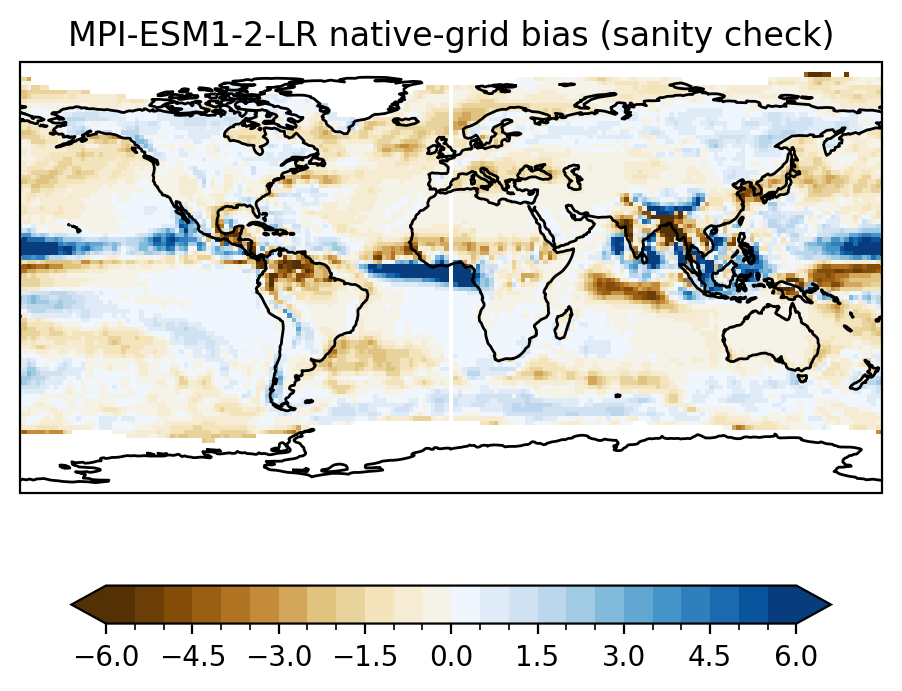

In [10]:
dcmap, _, _, _ = get_settings(field='precip', diff=True)
_check_levels = np.linspace(-6, 6, 25)
_check_norm = mpl.colors.BoundaryNorm(_check_levels, dcmap.N)

fig, ax = plt.subplots(figsize=(7, 4), subplot_kw={'projection': ccrs.PlateCarree()})
check_field = amip_bias_native[coarsest_cfg]
cf = ax.pcolormesh(check_field.lon, check_field.lat, check_field,
                    cmap=dcmap, norm=_check_norm, transform=ccrs.PlateCarree())
ax.coastlines(linewidth=1)
ax.set_global()
ax.set_title(f'{coarsest_cfg} native-grid bias (sanity check)')
fig.colorbar(cf, ax=ax, orientation='horizontal', shrink=0.7, extend='both')
plt.show()


## Final figure: CMIP vs. AMIP ensemble-mean JAS precipitation bias

In [8]:
coords_map, regions = nam_regions()
domains = list(coords_map.keys())

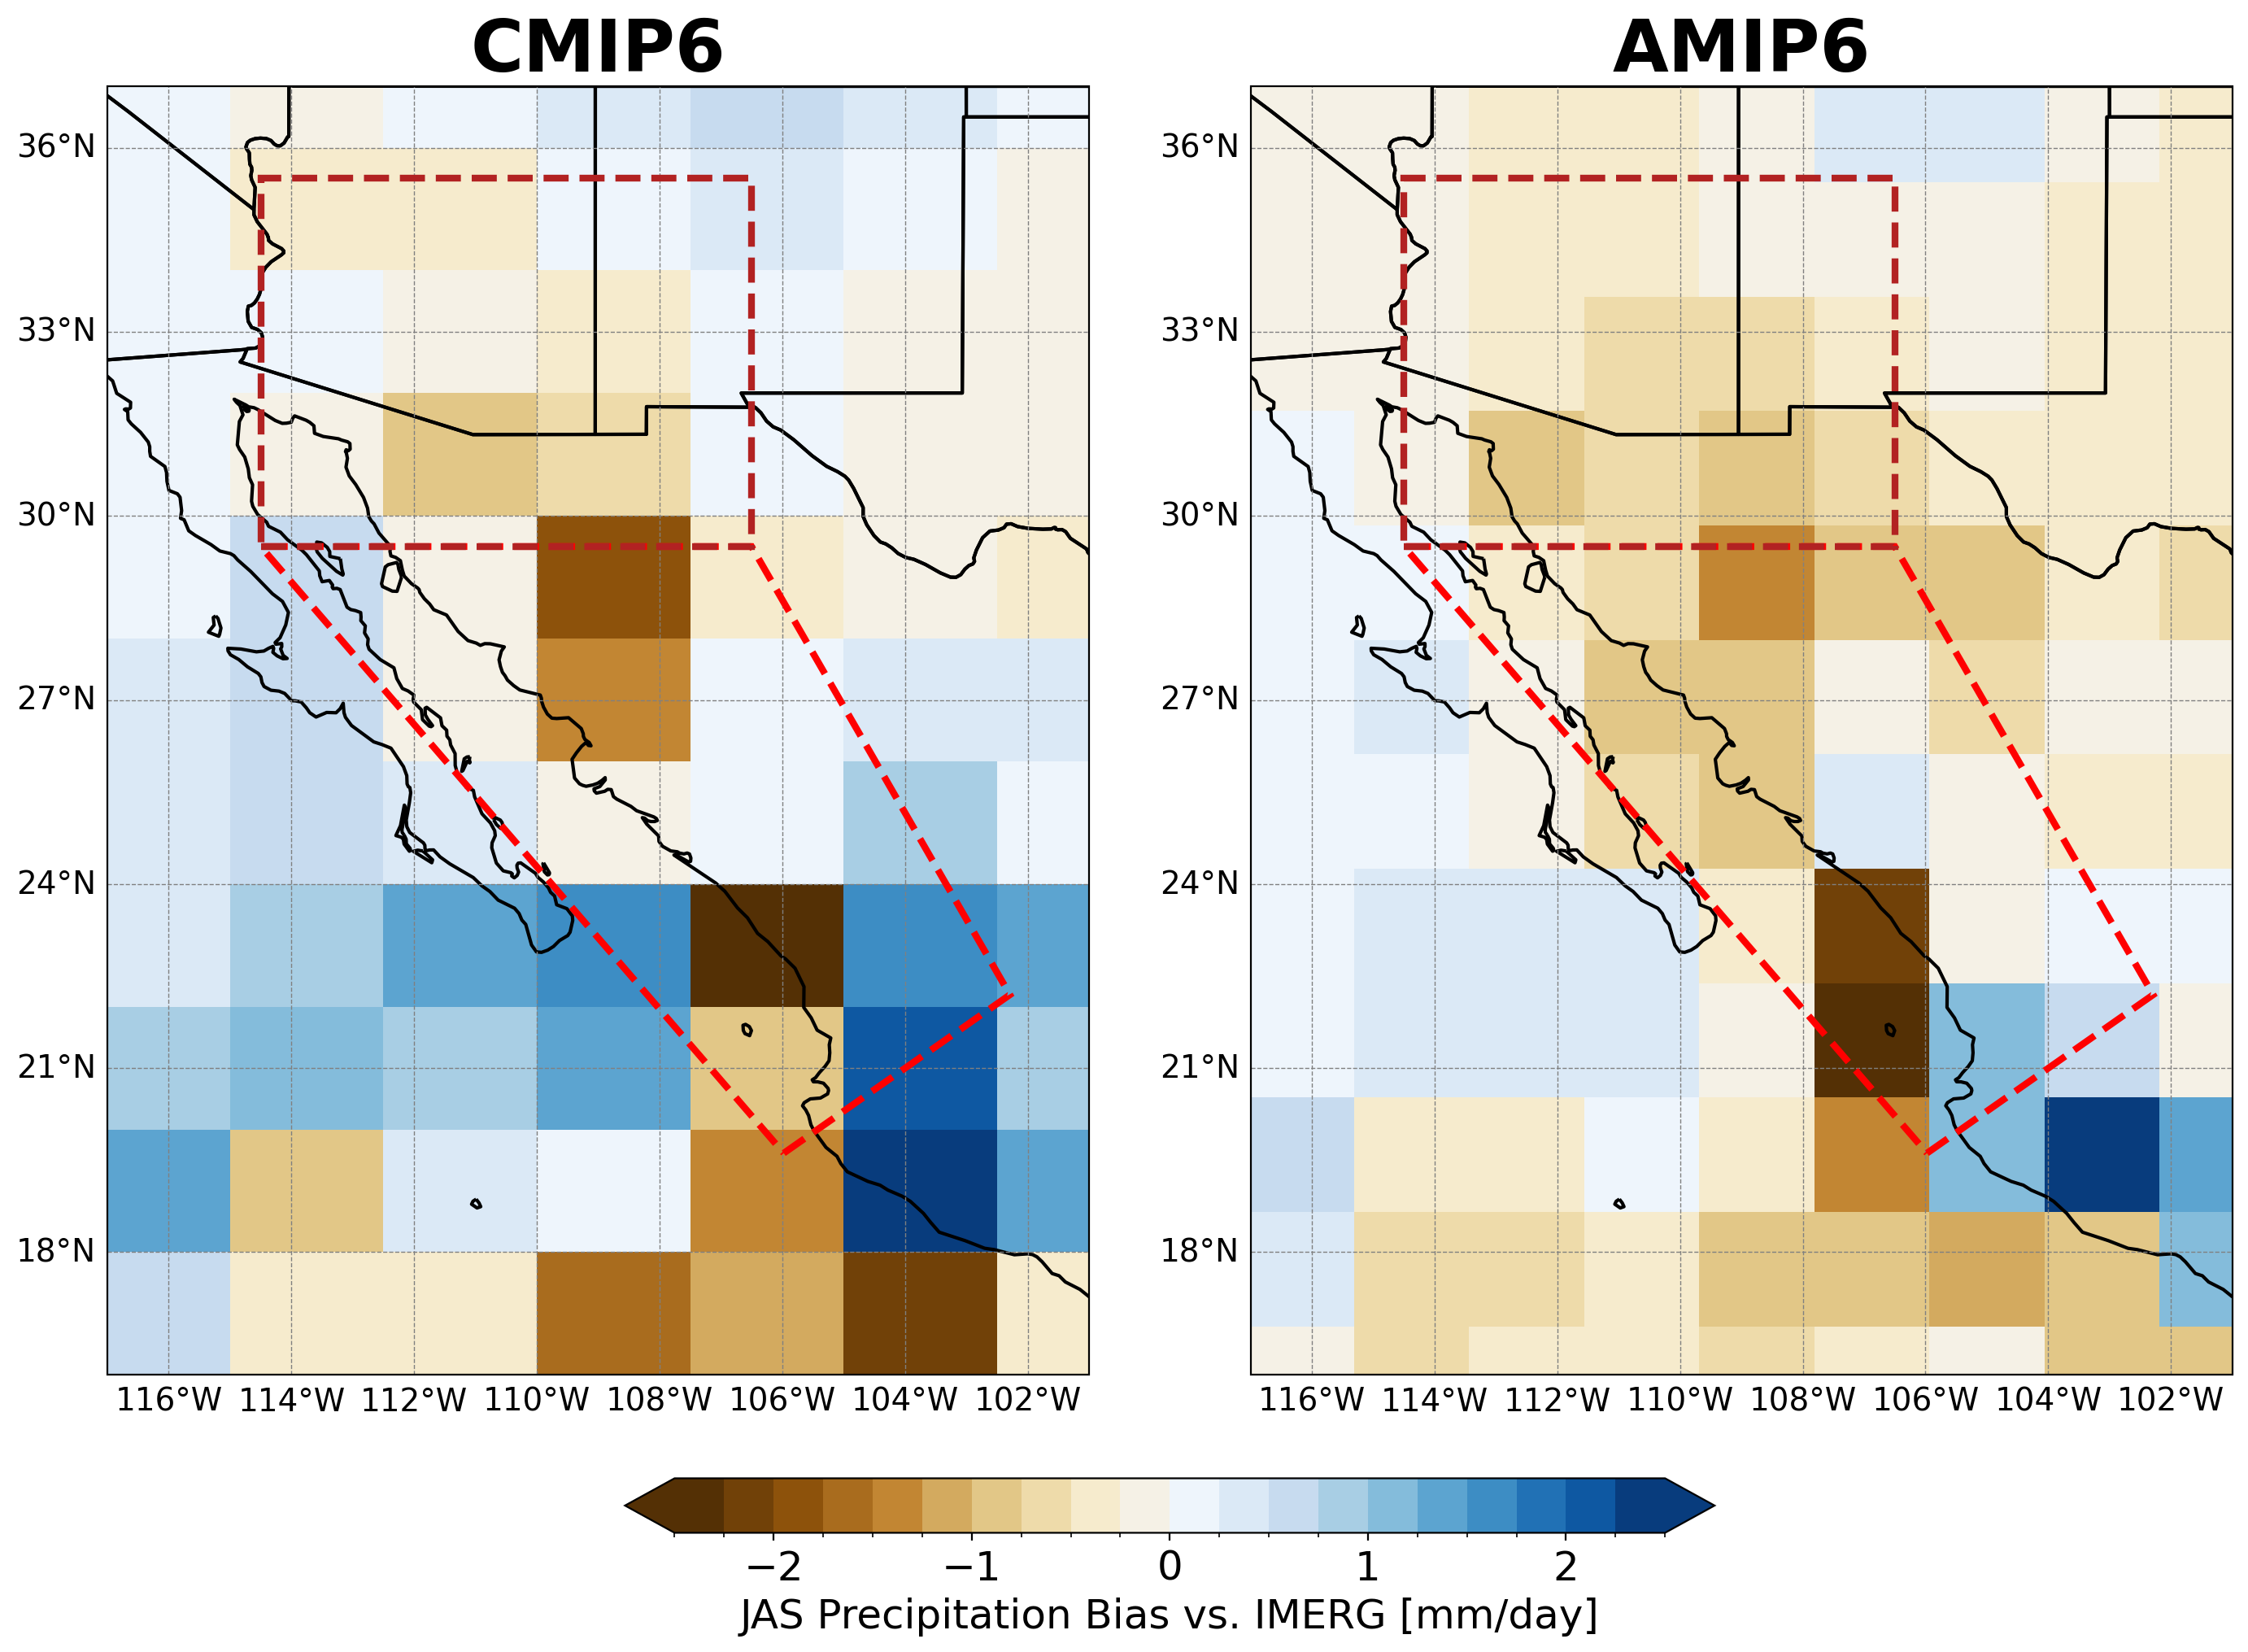

In [19]:
dcmap, _, _, _ = get_settings(field='precip', diff=True)   # combine_cmaps(BrBG, Blues)
dlevels = np.linspace(-2.5, 2.5, 21)                            # get_settings' own diff bounds (global map)
dnorm = mpl.colors.BoundaryNorm(dlevels, dcmap.N)
map_bnds=[243,259,16,37]

fig, axes = plt.subplots(1, 2, figsize=(14, 10),
                          subplot_kw={'projection': ccrs.PlateCarree()},
                          constrained_layout=True)

for ax, field, title in zip(axes, [bias_cmip, amip_mme], ['CMIP6', 'AMIP6']):
    cf = ax.pcolormesh(field.lon, field.lat, field, cmap=dcmap, norm=dnorm,
                        transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.5)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1.5)
    ax.set_extent(map_bnds, crs=ccrs.PlateCarree())
    gl = ax.gridlines(crs=ccrs.PlateCarree(), lw=.5, color='gray', linestyle='--', draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size':14}; gl.ylabel_style = {'size':14}
    ax.set_title(title, fontsize=32, fontweight='bold')

    # boxes around NAM subdomains
    poly1=patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=3, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
    poly2=patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=3, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly2)
    
cbar = fig.colorbar(cf, ticks=[-2,-1,0,1,2], ax=axes, orientation='horizontal', shrink=0.5, pad=0.04, extend='both')
cbar.set_label('JAS Precipitation Bias vs. IMERG [mm/day]', fontsize=18)
cbar.ax.tick_params(labelsize=18)

#fig.savefig(dpath_figs + 'cmip6_amip6_jas_prec_bias_mme.pdf', bbox_inches='tight')
#fig.savefig(dpath_figs + 'cmip6_amip6_jas_prec_bias_mme.png', bbox_inches='tight', dpi=200)
plt.show()


## Verification checklist

1. Run top-to-bottom in the `climate` conda environment/kernel on Discover -- all data now lives
   under `dpath0`, no other filesystem access needed.
2. Confirm CMIP6 ensemble count prints `49`; confirm all 6 AMIP configs load without a
   missing-file error and each prints a native grid size.
3. Confirm unit-converted JAS values are physically plausible (e.g. Amazon-box mean ~4-10 mm/day),
   not implausible (near-zero or >100) -- this validates the `*86400`/`*24` unit assumptions since
   neither the CMIP6 nor IMERG climatology file has a units attribute.
4. Inspect the printed native grid sizes for the 6 AMIP configs and the chosen `coarsest_cfg`.
5. Inspect the single-model sanity bias plot for grid artifacts/seams before trusting `amip_mme`.
6. Open the final saved PNG/PDF and confirm both panels are titled "CMIP" and "AMIP", the colorbar
   range isn't badly saturated, and there are no dateline/pole seams in the AMIP panel.
